# SLEAP Tutorial at Cosyne 2024 - Using exported data

## Setup

In [ ]:
!pip install sleap-io

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.9/137.9 kB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 14.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 339.4/339.4 kB 29.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.8/117.8 kB 12.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.7/526.7 kB 29.2 MB/s eta 0:00:00


In [ ]:
!wget https://github.com/talmolab/cosyne-tutorial-data/raw/main/new_data/results.zip
!unzip results.zip

--2024-02-28 12:14:40--  https://github.com/talmolab/cosyne-tutorial-data/raw/main/new_data/results.zip
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/talmolab/cosyne-tutorial-data/main/new_data/results.zip [following]
--2024-02-28 12:14:40--  https://raw.githubusercontent.com/talmolab/cosyne-tutorial-data/main/new_data/results.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6024596 (5.7M) [application/zip]
Saving to: ‘results.zip’

results.zip         100%[===================>]   5.75M  --.-KB/s    in 0.04s   

2024-02-28 12:14:40 (151 MB/s) - ‘results.zip’ saved [6024596/6024596]

Archive

## Using CSV

In [ ]:
import pandas as pd

df = pd.read_csv("new_video.v002.000_mice_new.analysis.csv")
df

,track,frame_idx,instance.score,head.x,head.y,head.score,torso.x,torso.y,torso.score,tail_base.x,tail_base.y,tail_base.score
0,track_0,0,0.452409,566.795776,248.926422,0.775533,477.049164,276.195312,0.840341,416.618591,289.079529,0.641716
1,track_0,1,0.423293,579.212158,252.098877,0.524509,491.916687,268.133301,0.864011,428.593292,252.568268,0.502443
2,track_1,1,0.230167,475.953583,427.969421,1.023815,480.214294,364.235413,0.990409,NaN,NaN,0.000000
3,track_0,2,0.404776,595.261230,255.998260,0.438605,508.075378,260.352478,0.902620,444.067688,272.276764,0.773855
4,track_1,2,0.292742,476.059387,428.079468,0.965847,480.260010,368.213043,1.030145,492.502716,320.770325,0.225987
...,...,...,...,...,...,...,...,...,...,...,...,...
5555,track_1,2817,0.549521,604.961792,452.139648,0.537645,556.229675,436.371429,0.955967,520.295044,376.658691,0.806471
5556,track_0,2818,0.441821,412.508972,596.676331,0.742932,360.331940,556.807678,0.841093,292.633972,564.353821,0.851277
5557,track_1,2818,0.565165,609.180847,451.996338,0.756140,556.315918,436.330292,0.970995,516.091919,376.808502,0.851646
5558,track_0,2819,0.446245,411.902161,600.478394,0.762012,360.342468,556.984985,0.854819,292.555084,564.564758,0.847509


<Axes: xlabel='head.x', ylabel='head.y'>

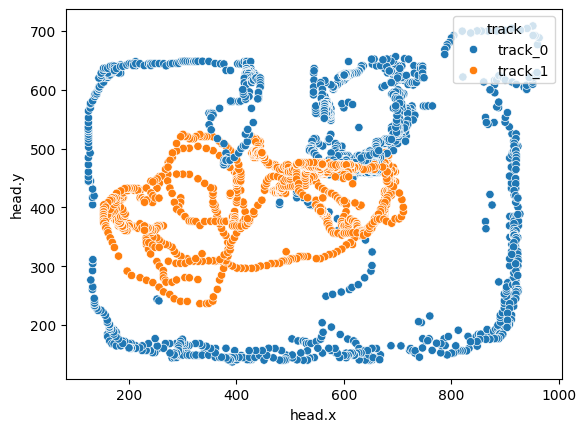

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.scatterplot(data=df, x="head.x", y="head.y", hue="track")

## Using HDF5

In [ ]:
import h5py


with h5py.File("new_video.v002.000_mice_new.analysis.h5", "r") as f:
    tracks = f["tracks"][:].transpose(3, 1, 2, 0)

tracks.shape  # (frames, tracks, nodes, xy)

(2820, 2, 3, 2)

<ipython-input-6-ec13c23896fb>:3: RuntimeWarning: Mean of empty slice
  vel = np.nanmean(np.linalg.norm(np.diff(tracks, axis=0), axis=-1), axis=-1)


vel.shape = (2819, 2)


Text(0.5, 0, 'Velocity (px/frame)')

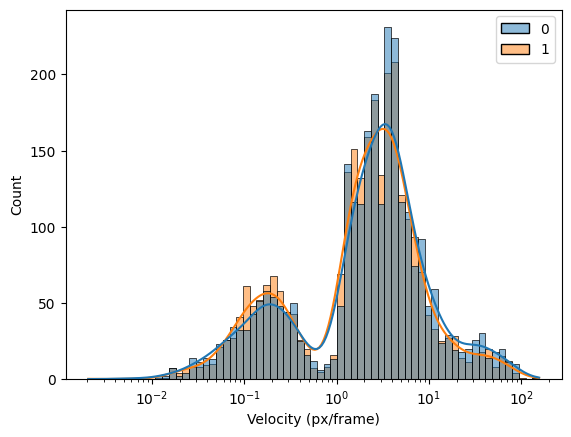

In [ ]:
import numpy as np

vel = np.nanmean(np.linalg.norm(np.diff(tracks, axis=0), axis=-1), axis=-1)
print("vel.shape =", vel.shape)

sns.histplot(vel, kde=True, log_scale=True)
plt.xlabel("Velocity (px/frame)")

In [ ]:
def print_hdf5_info(obj, indent=0):
    """Recursively prints information about datasets and groups in an HDF5 file."""
    if isinstance(obj, h5py.File) or isinstance(obj, h5py.Group):
        for key in obj.keys():
            print(' ' * indent + f"{'/' if indent == 0 else ''}{key}:")
            print_hdf5_info(obj[key], indent + 4)
    elif isinstance(obj, h5py.Dataset):
        print(' ' * indent + f"{'/' if indent == 0 else ''}{obj.name} (Dataset)")
        print(' ' * (indent + 4) + f"Shape: {obj.shape}")
        print(' ' * (indent + 4) + f"Dtype: {obj.dtype}")
        if obj.attrs:
            print(' ' * (indent + 4) + "Attributes:")
            for attr_name, attr_value in obj.attrs.items():
                print(' ' * (indent + 8) + f"{attr_name}: {attr_value}")
    else:
        print(' ' * indent + f"Unknown object: {obj}")


with h5py.File("new_video.v002.000_mice_new.analysis.h5", "r") as f:
    print_hdf5_info(f)

/edge_inds:
    /edge_inds (Dataset)
        Shape: (2, 2)
        Dtype: int64
/edge_names:
    /edge_names (Dataset)
        Shape: (2, 2)
        Dtype: |S9
/instance_scores:
    /instance_scores (Dataset)
        Shape: (2, 2820)
        Dtype: float64
/labels_path:
    /labels_path (Dataset)
        Shape: ()
        Dtype: object
/node_names:
    /node_names (Dataset)
        Shape: (3,)
        Dtype: |S9
/point_scores:
    /point_scores (Dataset)
        Shape: (2, 3, 2820)
        Dtype: float64
/provenance:
    /provenance (Dataset)
        Shape: ()
        Dtype: object
/track_names:
    /track_names (Dataset)
        Shape: (2,)
        Dtype: |S7
/track_occupancy:
    /track_occupancy (Dataset)
        Shape: (2820, 2)
        Dtype: uint8
/tracking_scores:
    /tracking_scores (Dataset)
        Shape: (2, 2820)
        Dtype: float64
/tracks:
    /tracks (Dataset)
        Shape: (2, 2, 3, 2820)
        Dtype: float64
/video_ind:
    /video_ind (Dataset)
        Shape: ()

## Using sleap-io



In [ ]:
import sleap_io as sio

In [ ]:
predictions = sio.load_nwb("new_video.v002.slp.nwb")
predictions

/usr/local/lib/python3.10/dist-packages/hdmf/utils.py:668: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.6.0 because version 1.8.0 is already loaded.
  return func(args[0], **pargs)
/usr/local/lib/python3.10/dist-packages/hdmf/utils.py:668: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.3.0 because version 0.5.0 is already loaded.
  return func(args[0], **pargs)


Labels(labeled_frames=2820, videos=1, skeletons=1, tracks=2)

In [ ]:
predictions = sio.load_slp("new_video.v002.slp")
predictions

Labels(labeled_frames=2820, videos=1, skeletons=1, tracks=2)

In [ ]:
tracks = predictions.numpy()
tracks.shape  # (frames, tracks, nodes, xy)

(2820, 2, 3, 2)

In [ ]:
idx = 0

lf = predictions[idx]
lf

LabeledFrame(video=Video(filename="mice_new.mp4", shape=(2820, 768, 1024, 1), backend=MediaVideo), frame_idx=0, instances=[PredictedInstance(points={Node(name='head'): PredictedPoint(x=566.7957763671875, y=248.92642211914062, visible=True, complete=False, score=0.7755330204963684), Node(name='torso'): PredictedPoint(x=477.0491638183594, y=276.1953125, visible=True, complete=False, score=0.8403405547142029), Node(name='tail_base'): PredictedPoint(x=416.61859130859375, y=289.07952880859375, visible=True, complete=False, score=0.6417162418365479)}, skeleton=Skeleton(nodes=[Node(name='head'), Node(name='torso'), Node(name='tail_base')], edges=[Edge(source=Node(name='torso'), destination=Node(name='head')), Edge(source=Node(name='torso'), destination=Node(name='tail_base'))], symmetries=[], name='Skeleton-1'), track=Track(name='track_0'), from_predicted=None, score=0.45240876, tracking_score=0.0)])

In [ ]:
def imgfig(size = 6, dpi = 72, scale = 1.0):
    """Create a tight figure for image plotting.

    Args:
        size: Scalar or 2-tuple specifying the (width, height) of the figure in inches.
            If scalar, will assume equal width and height.
        dpi: Dots per inch, controlling the resolution of the image.
        scale: Factor to scale the size of the figure by. This is a convenience for
            increasing the size of the plot at the same DPI.

    Returns:
        A matplotlib.figure.Figure to use for plotting.
    """
    if not isinstance(size, (tuple, list)):
        size = (size, size)
    fig = plt.figure(figsize=(scale * size[0], scale * size[1]), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1], frameon=False)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.autoscale(tight=True)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    return fig


def plot_instance(instance):
    pts = instance.numpy()

    cmap = sns.color_palette("tab10")
    for k, (src, dst) in enumerate(instance.skeleton.edge_inds):
        plt.plot(pts[(src, dst), 0], pts[(src, dst), 1], ".-", ms=15, lw=3, c=cmap[k])

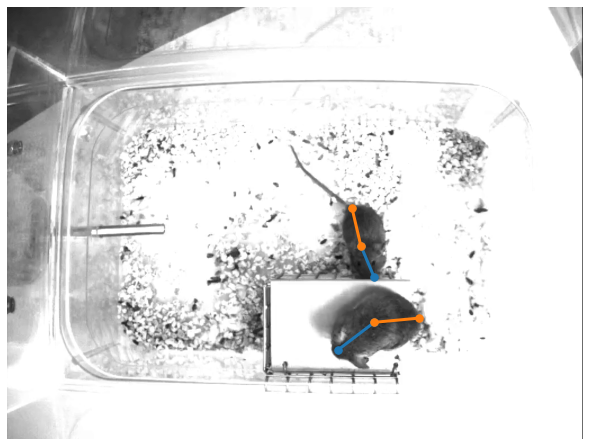

In [ ]:
# @title  { run: "auto" }

idx = 752 # @param {type:"slider", min:0, max:2819, step:1}

lf = predictions[idx]

fig = imgfig(size=8)
plt.imshow(lf.image.squeeze(), cmap="gray")
for instance in lf:
    plot_instance(instance)